In [29]:
!pip install annoy

In [30]:
from annoy import AnnoyIndex
import numpy as np
import pandas as pd
import joblib

In [31]:
df = pd.read_csv("train_vectors.csv")
filenames = df["filename"].values
vectors = df.drop(columns=["filename"]).values

In [32]:
model = joblib.load('CNN.sav')

In [33]:
vector_dim = vectors.shape[1]
ann_index = AnnoyIndex(vector_dim, metric='euclidean')

for i, v in enumerate(vectors):
    ann_index.add_item(i, v.tolist())

ann_index.build(1000)
ann_index.save("image_features.ann")

True

In [34]:
def extract_feature(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    features = model.predict(x, verbose=0)
    return features.flatten()

In [35]:
def find_similar_images(img_path, top_k=10):
    query_vec = extract_feature(img_path)
    idxs = ann_index.get_nns_by_vector(query_vec, top_k, include_distances=True)
    results = [(filenames[i], d) for i, d in zip(idxs[0], idxs[1])]
    return results

In [36]:
queryImg = "180.jpg"
similar = find_similar_images(queryImg)

for fname, dist in similar:
    print(f"{fname}  (distance={dist:.4f})")

Stonehenge/1.stonehenge-from-ne.jpg  (distance=44.0584)
Chich-n Itz - Mexico/8.mexico-chiche-itza-260nw-787007947.jpg  (distance=44.0678)
Taj Mahal - India/152.jpg  (distance=44.1564)
Pyramids Of Giza - Egypt/87.pyramid-of-khafre-giza-egypt-3-800x369.jpg  (distance=44.1901)
The Blue Grotto - Capri/45.jpg  (distance=44.2433)
Venezuela Angel Falls/8.jpg  (distance=44.2463)
Statue Of Liberty - NYC/24.jpg  (distance=44.2599)
Burj Khalifa - UAE/6.dubai-skyline-burj-khalifa-skyscraper-panorama-panoramic-aerial-view-K10XM2.jpg  (distance=44.2601)
Niagara Falls/50.jpg  (distance=44.2611)
Burj Khalifa - UAE/3.jpg  (distance=44.2679)


In [37]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [38]:
similar

[('Stonehenge/1.stonehenge-from-ne.jpg', 44.05843734741211),
 ('Chich-n Itz - Mexico/8.mexico-chiche-itza-260nw-787007947.jpg',
  44.06777572631836),
 ('Taj Mahal - India/152.jpg', 44.15641784667969),
 ('Pyramids Of Giza - Egypt/87.pyramid-of-khafre-giza-egypt-3-800x369.jpg',
  44.1900634765625),
 ('The Blue Grotto - Capri/45.jpg', 44.24325180053711),
 ('Venezuela Angel Falls/8.jpg', 44.24634552001953),
 ('Statue Of Liberty - NYC/24.jpg', 44.2598991394043),
 ('Burj Khalifa - UAE/6.dubai-skyline-burj-khalifa-skyscraper-panorama-panoramic-aerial-view-K10XM2.jpg',
  44.260074615478516),
 ('Niagara Falls/50.jpg', 44.26108169555664),
 ('Burj Khalifa - UAE/3.jpg', 44.26786422729492)]

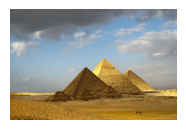

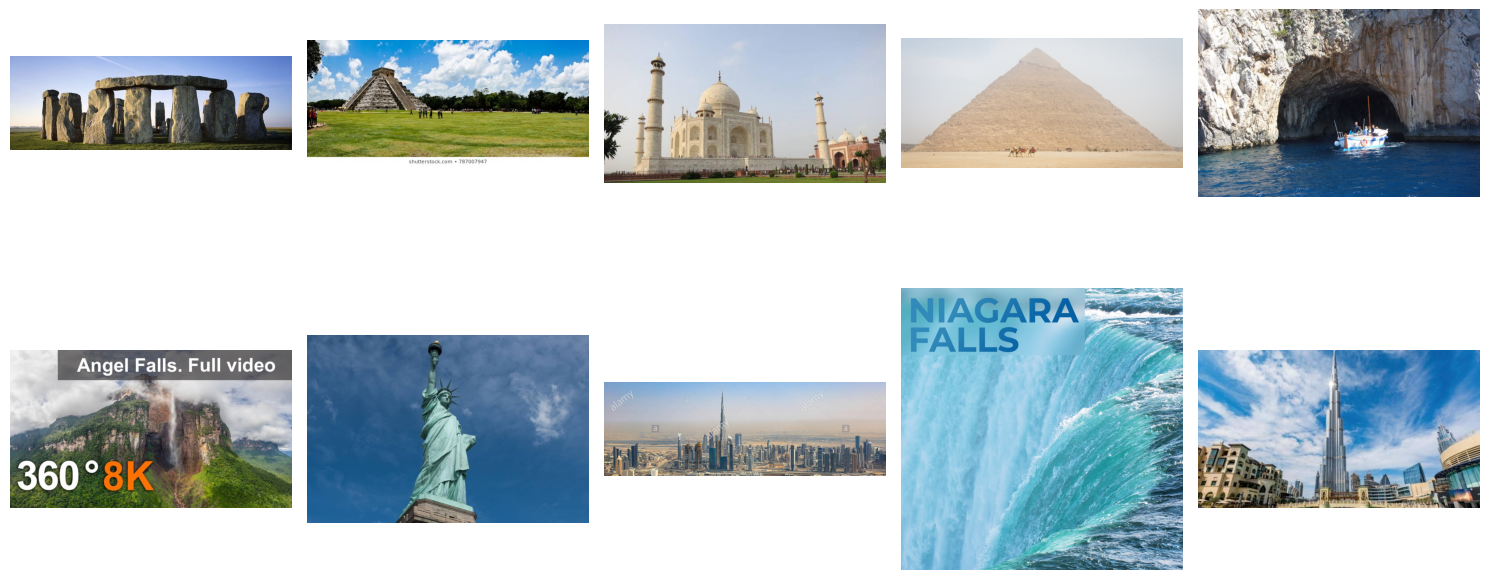

In [39]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

similar = find_similar_images(queryImg)
pathh = '/content/gdrive/MyDrive/train'

plt.figure(figsize=(15, 8))
plt.subplot(2, 6, 1)
img = mpimg.imread(queryImg)
plt.imshow(img)
plt.axis('off')
plt.show()

plt.figure(figsize=(15, 8))
for i, (fname, dist) in enumerate(similar[:10], start=1):
    plt.subplot(2, 5, i)
    similar_image_full_path = os.path.join(pathh, fname)
    img = mpimg.imread(similar_image_full_path)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()